# Dominio 1: Sistema Financiero (Banco Central de Chile)

Datos reales, sin autenticación, vía la API pública de `mindicador.cl` (que
replica series del Banco Central de Chile): dólar observado y UF (diarios,
2013-2026), TPM/IPC/IMACEC (mensuales). Panel alineado a una única grilla
diaria, modelo que predice el **retorno logarítmico del dólar al día
siguiente**.

Este notebook ejecuta el pipeline real de `src/domains/financial_bcch/`
(no reimplementa su lógica) y muestra sus resultados.


## 1. Limpieza

Alinea 5 indicadores de frecuencias distintas a una grilla diaria, corrige un error real de datos encontrado en la API (ver más abajo), y winsoriza outliers de mercado genuinos.


In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
from src.domains.financial_bcch.clean import build_clean_panel

panel, report = build_clean_panel()
for k, v in report.items():
    if not isinstance(v, pd.Series):
        print(f"{k}: {v}")


dolar_dupes_exactas: 0
dolar_filas_creadas_por_calendario: 1589
dolar_errores_de_nivel_corregidos: 0
uf_dupes_exactas: 0
uf_filas_creadas_por_calendario: 2
uf_errores_de_nivel_corregidos: 2
tpm_dupes_exactas: 0
tpm_filas_creadas_por_calendario: 1615
dolar_log_return_outliers_winsorizados: 67
n_filas_finales: 4990


**Hallazgo real (no simulado)**: la API de `mindicador.cl` publicó un valor de
UF corrupto para 2014-12-29/30 (608.15 y 607.38, en vez de ~24.627 -- un error
de captura en la fuente, no un movimiento de mercado). Una comparación día a
día no lo detecta porque los dos días corruptos son parecidos ENTRE SÍ; se
corrigió con `fix_implausible_level_jumps` (`src/toolkit/outliers.py`), que
compara cada punto contra la mediana móvil de sus vecinos, no contra el día
anterior.


## 2. Features y modelado (>=100 épocas)


In [2]:
from src.domains.financial_bcch.features import build_features
from src.domains.financial_bcch.model import train_all_models

features_df = build_features(panel)
print(f"{len(features_df):,} filas x features reales, sin look-ahead")
features_df.tail()


4,969 filas x features reales, sin look-ahead


,fecha,dolar,uf,tpm,ipc,imacec,dolar_log_return,dolar_log_return_lag1,dolar_log_return_lag2,dolar_log_return_lag3,dolar_log_return_lag5,dolar_log_return_lag10,dolar_volatility_5d,dolar_volatility_10d,dolar_volatility_20d,uf_log_return,dow,month,target_next_return
4964,2026-08-27,918.42,40868.50,4.5,-0.2,-1.5,0.007640,-0.003516,-0.003852,-0.005496,0.000000,-0.000055,0.002465,0.004047,0.003218,0.000032,3,8,0.007409
4965,2026-08-28,925.25,40869.82,4.5,-0.2,-1.5,0.007409,0.007640,-0.003516,-0.003852,0.000000,0.001138,0.005252,0.004747,0.003610,0.000032,4,8,0.000000
4966,2026-08-29,925.25,40871.14,4.5,-0.2,-1.5,0.000000,0.007409,0.007640,-0.003516,-0.005496,0.008637,0.006514,0.005220,0.003948,0.000032,5,8,0.000000
4967,2026-08-30,925.25,40872.45,4.5,-0.2,-1.5,0.000000,0.000000,0.007409,0.007640,-0.003852,-0.002019,0.005671,0.004521,0.003948,0.000032,6,8,0.004239
4968,2026-08-31,929.18,40873.77,4.5,-0.2,-1.5,0.004239,0.000000,0.000000,0.007409,-0.003516,0.003222,0.004975,0.004449,0.003892,0.000032,0,8,0.004531


In [3]:
output = train_all_models(features_df)
pd.DataFrame(output["results"]).T


,r2,rmse,mae,epochs_run,best_epoch,early_stopped,best_iteration,alpha_relativo,alpha_efectivo,l1_ratio,...,n_coeficientes,n_coeficientes_no_nulos,max_depth,min_samples_leaf,n_estimators,features_mas_importantes,window,hidden,n_secuencias_train,n_test_con_relleno
baseline_media,-0.001232,0.005288,0.003505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mlp_pytorch,0.004046,0.005274,0.003538,400,400,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
xgboost,-0.002106,0.00529,0.003484,NaN,NaN,NaN,22.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elasticnet,-0.002293,0.00529,0.003498,NaN,NaN,NaN,NaN,0.1,0.000516,0.5,...,14.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
random_forest,-0.00545,0.005299,0.003476,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,4,5,300,"[{'feature': 'dow', 'importancia': 0.1507}, {'...",NaN,NaN,NaN,NaN
lstm,-0.008339,0.005306,0.003539,100,2,True,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,10,32,3469,0


**Resultado honesto**: los 6 enfoques (baseline, MLP, XGBoost, lineal
regularizado, Random Forest y LSTM) empatan alrededor de R²≈0 -- consistente
con la Hipótesis de Mercados Eficientes: el retorno diario del dólar no tiene
señal explotable con estas features. El lineal regularizado lo dice de la forma
más directa: deja 1 de 14 coeficientes en pie y termina prediciendo poco más que
la media de train. La MLP
usa `LeakyReLU` en vez de `ReLU` a propósito -- con `ReLU` estándar la red
colapsaba por "dying ReLU" (R² medido hasta -8746 antes de corregirlo, ver
`src/domains/financial_bcch/model.py`).


## 3. Gráficos (cada uno generado por `src/toolkit/viz.py`)


**% de días de calendario sin publicación, antes/después de reindexar** -- dólar y TPM pierden ~32% de días (fines de semana/feriados), UF casi no pierde ninguno (publica todos los días del calendario, no solo hábiles).


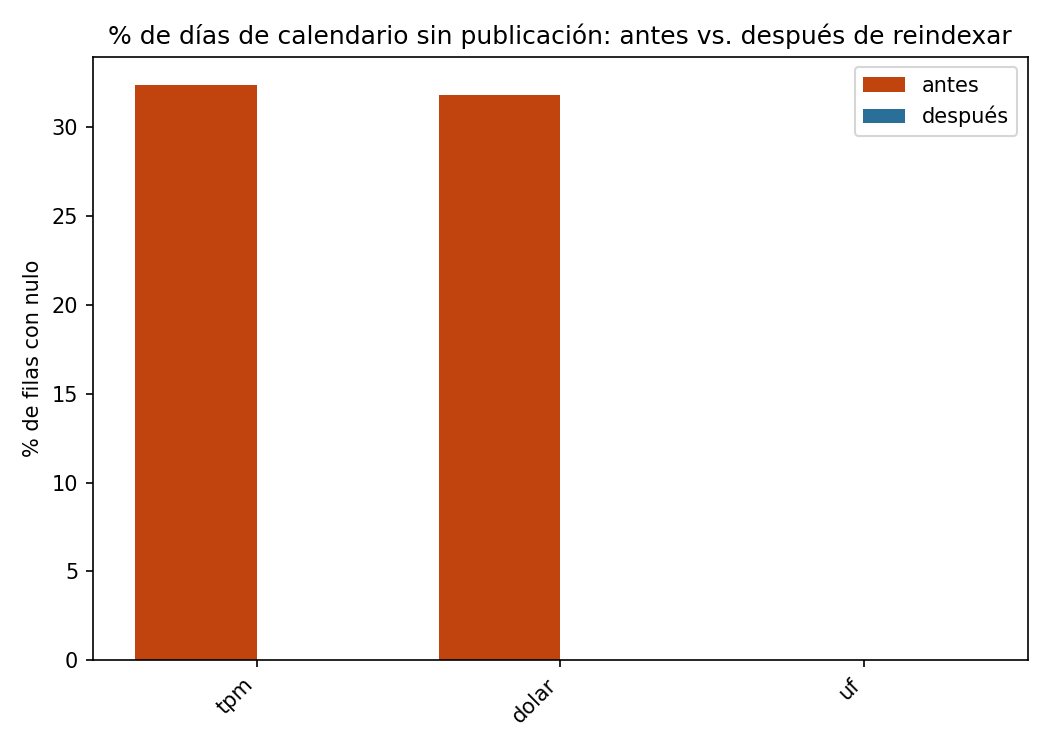

In [4]:
from IPython.display import Image, display
display(Image(filename="../outputs/financial/figures/missingness_before_after.png"))


**Distribución del retorno diario del dólar, crudo vs. winsorizado (IQR k=4)** -- se recortan solo las colas estadísticamente atípicas, preservando la volatilidad real de mercado.


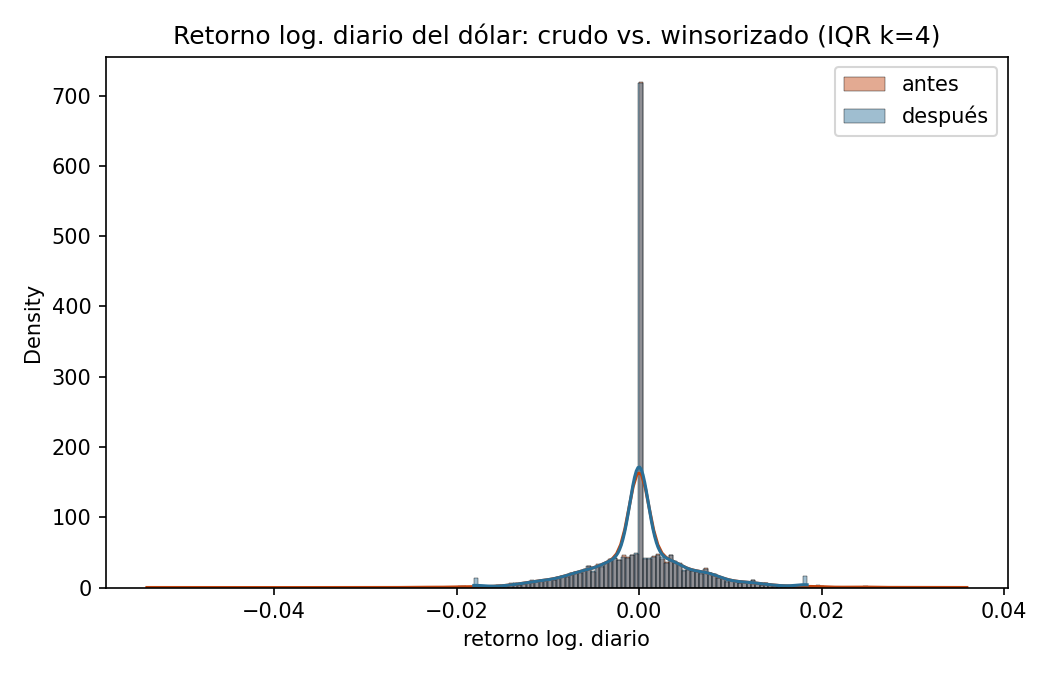

In [5]:
from IPython.display import Image, display
display(Image(filename="../outputs/financial/figures/return_distribution_before_after.png"))


**USD/CLP observado, historial completo con media móvil de 20 días.**


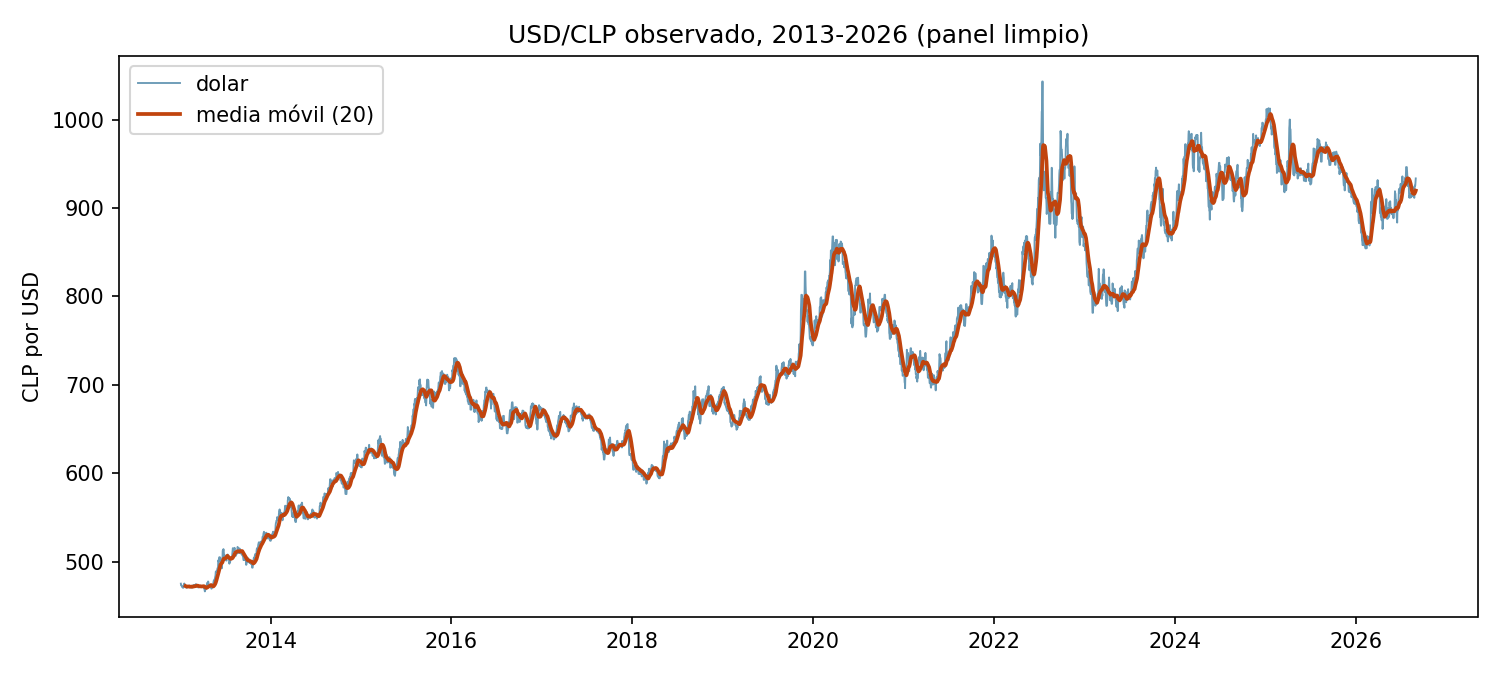

In [6]:
from IPython.display import Image, display
display(Image(filename="../outputs/financial/figures/dolar_timeseries.png"))


**Correlación entre features y el retorno del día siguiente** -- ninguna correlación individual es fuerte, coherente con el resultado del modelo.


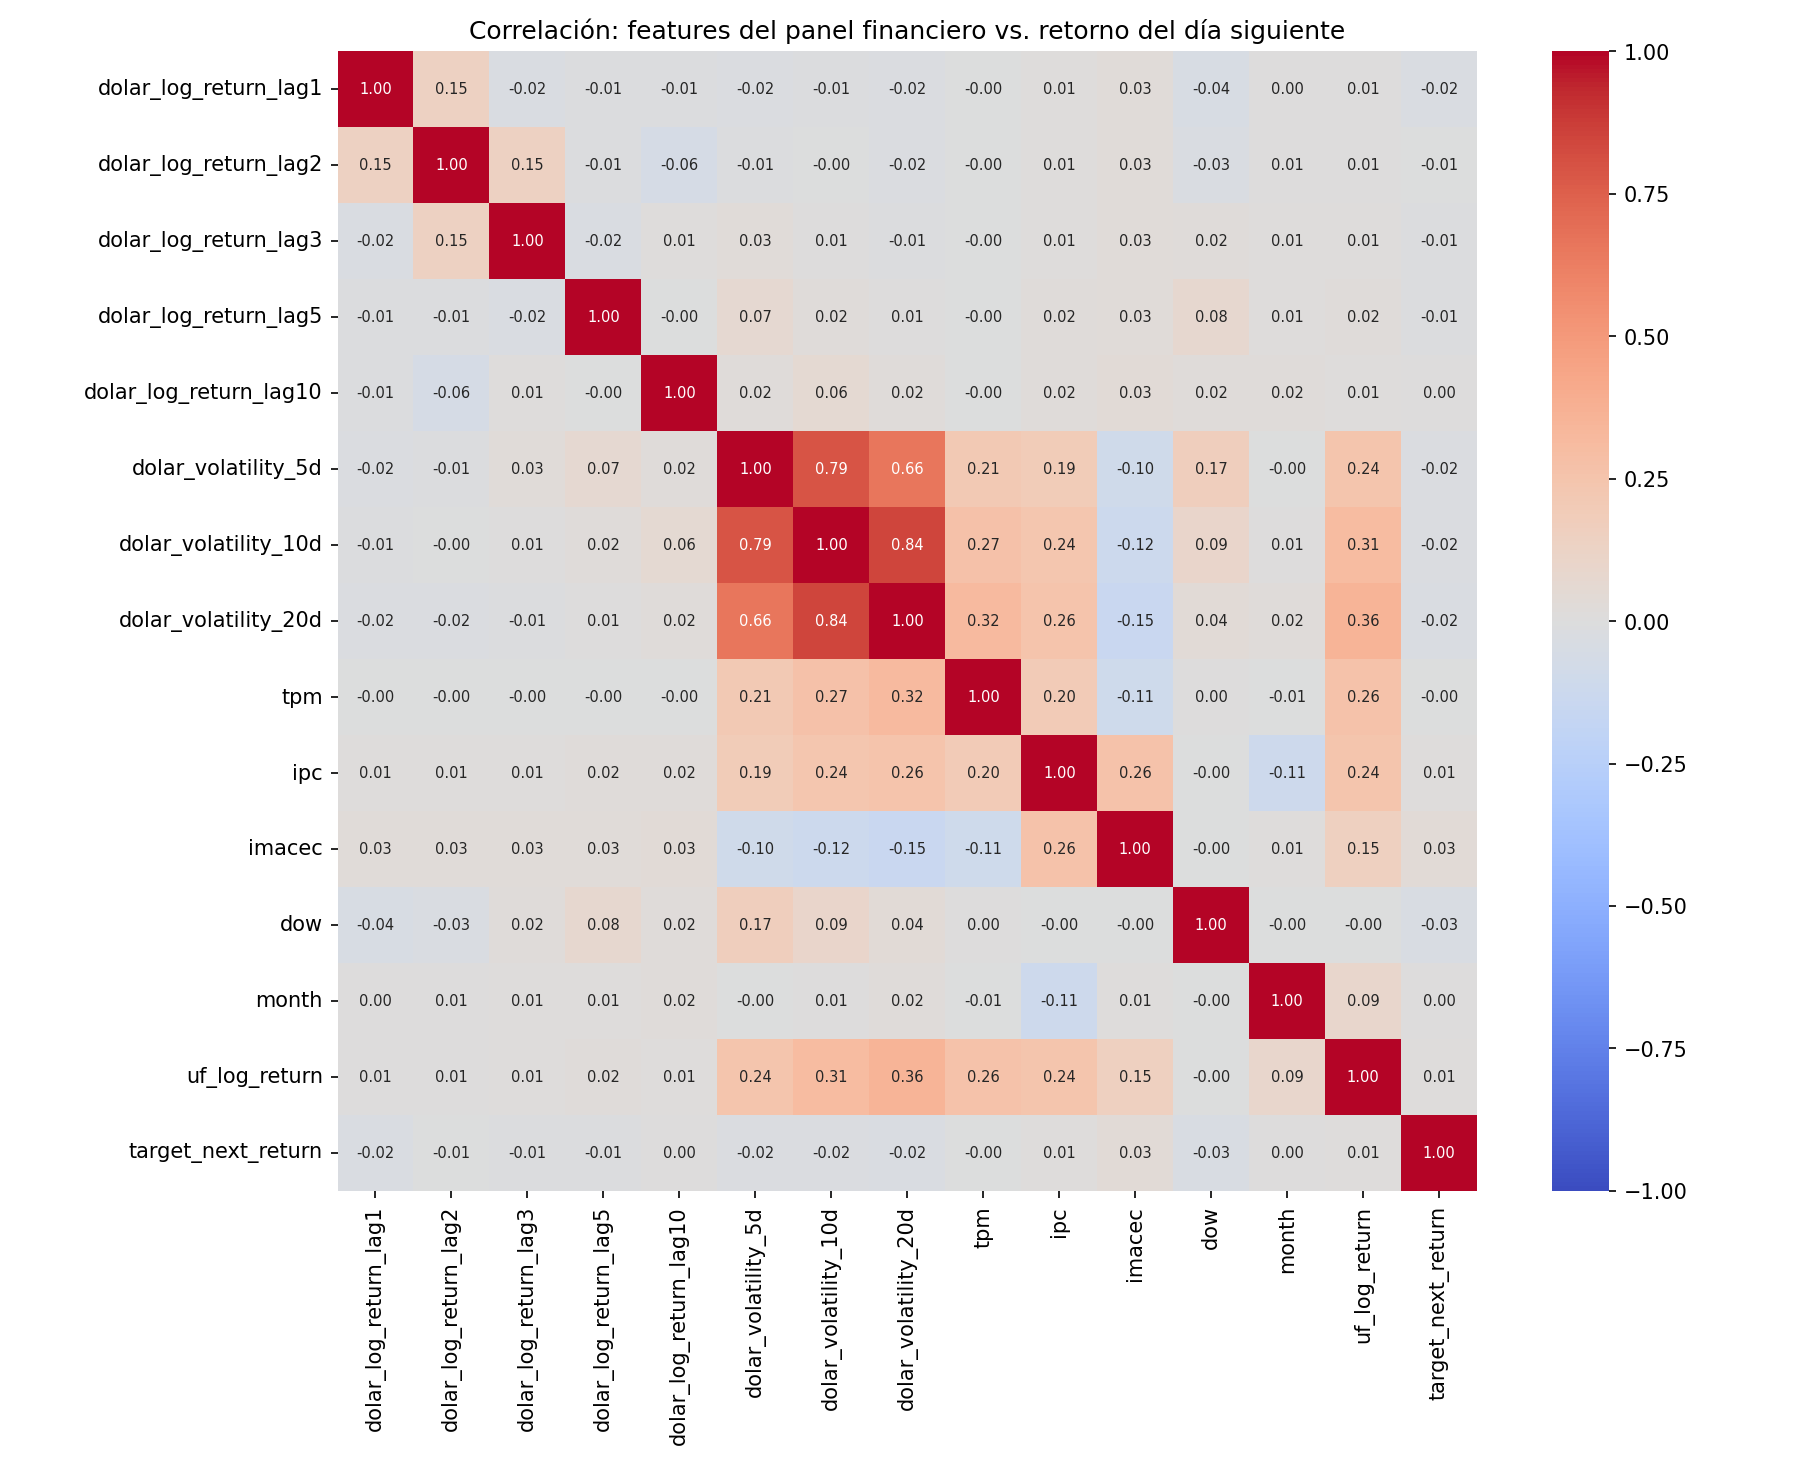

In [7]:
from IPython.display import Image, display
display(Image(filename="../outputs/financial/figures/feature_correlation.png"))


**Curva de entrenamiento de la MLP** -- >=100 épocas reales, mejor checkpoint marcado.


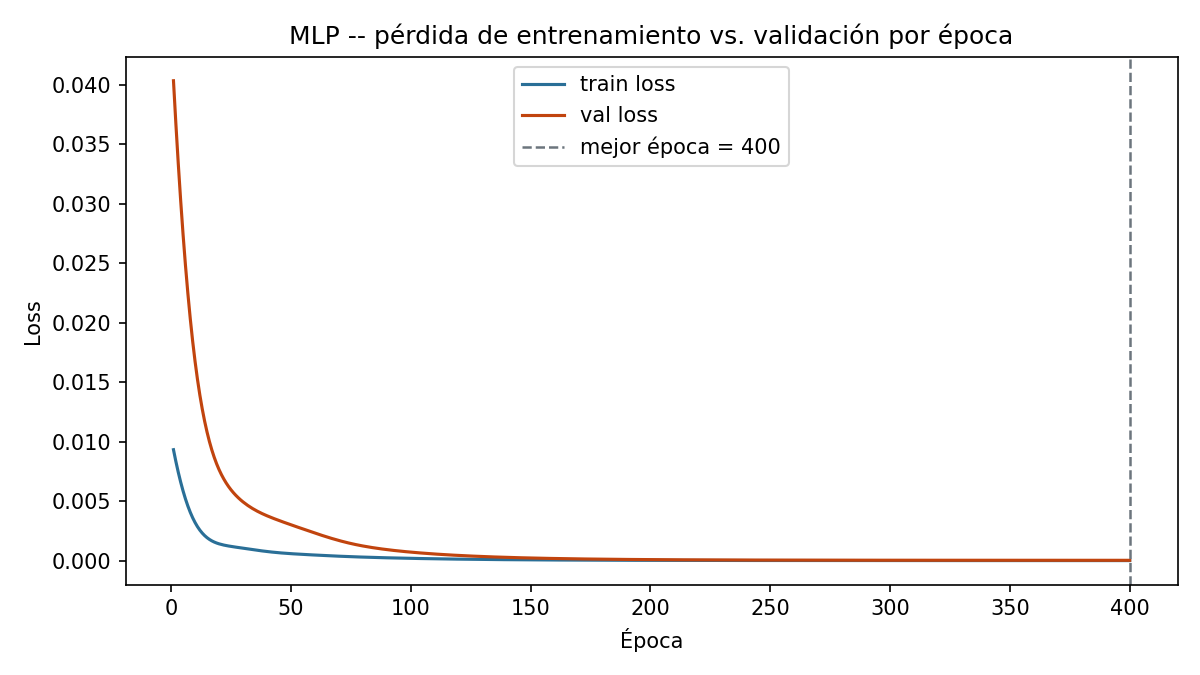

In [8]:
from IPython.display import Image, display
display(Image(filename="../outputs/financial/figures/mlp_training_curve.png"))


**Retorno real vs. predicho, mejor de los 6 modelos (holdout cronológico)** -- la nube dispersa alrededor de una línea plana es la firma visual de un R²≈0.


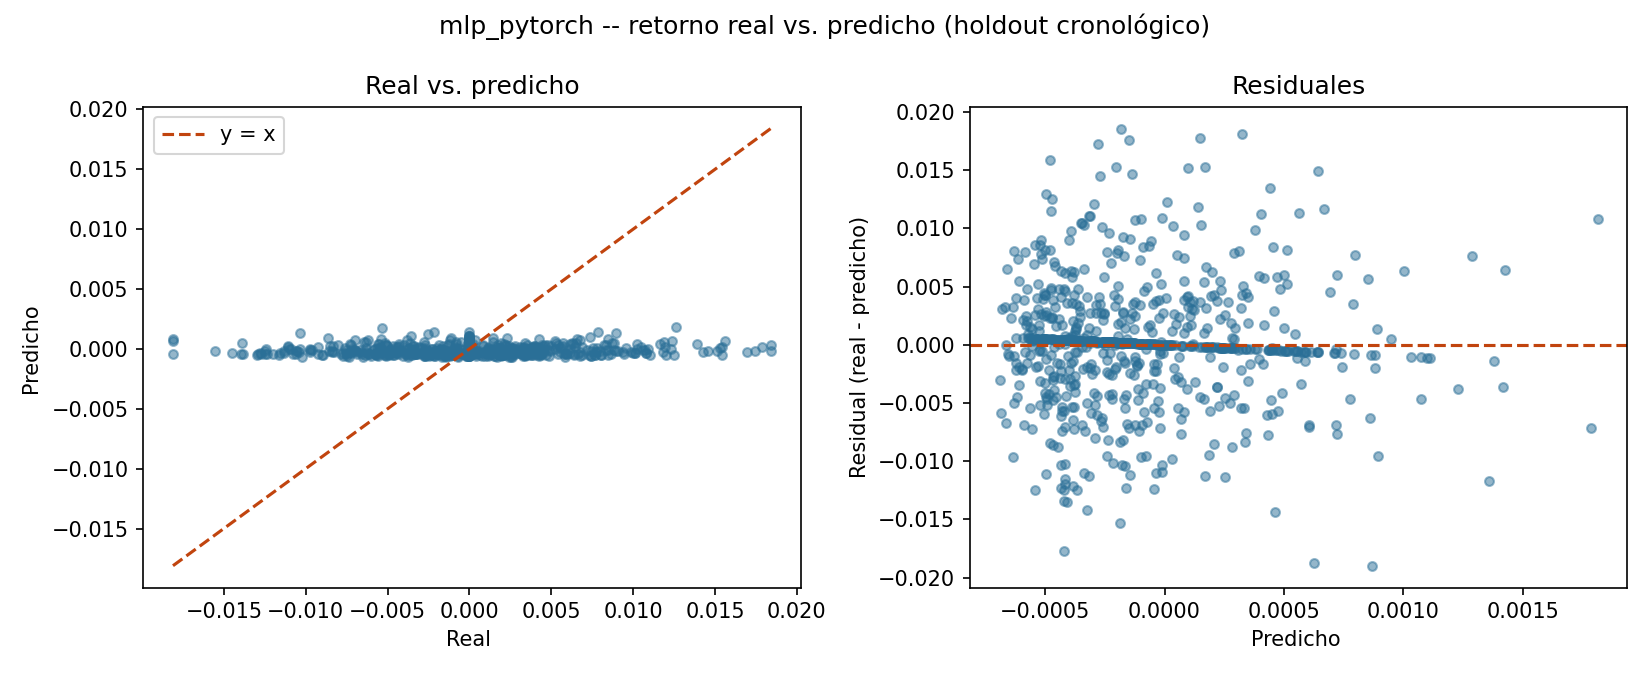

In [9]:
from IPython.display import Image, display
display(Image(filename="../outputs/financial/figures/best_model_regression_diagnostics.png"))


**Comparación de los 6 modelos** -- los seis prácticamente empatan.


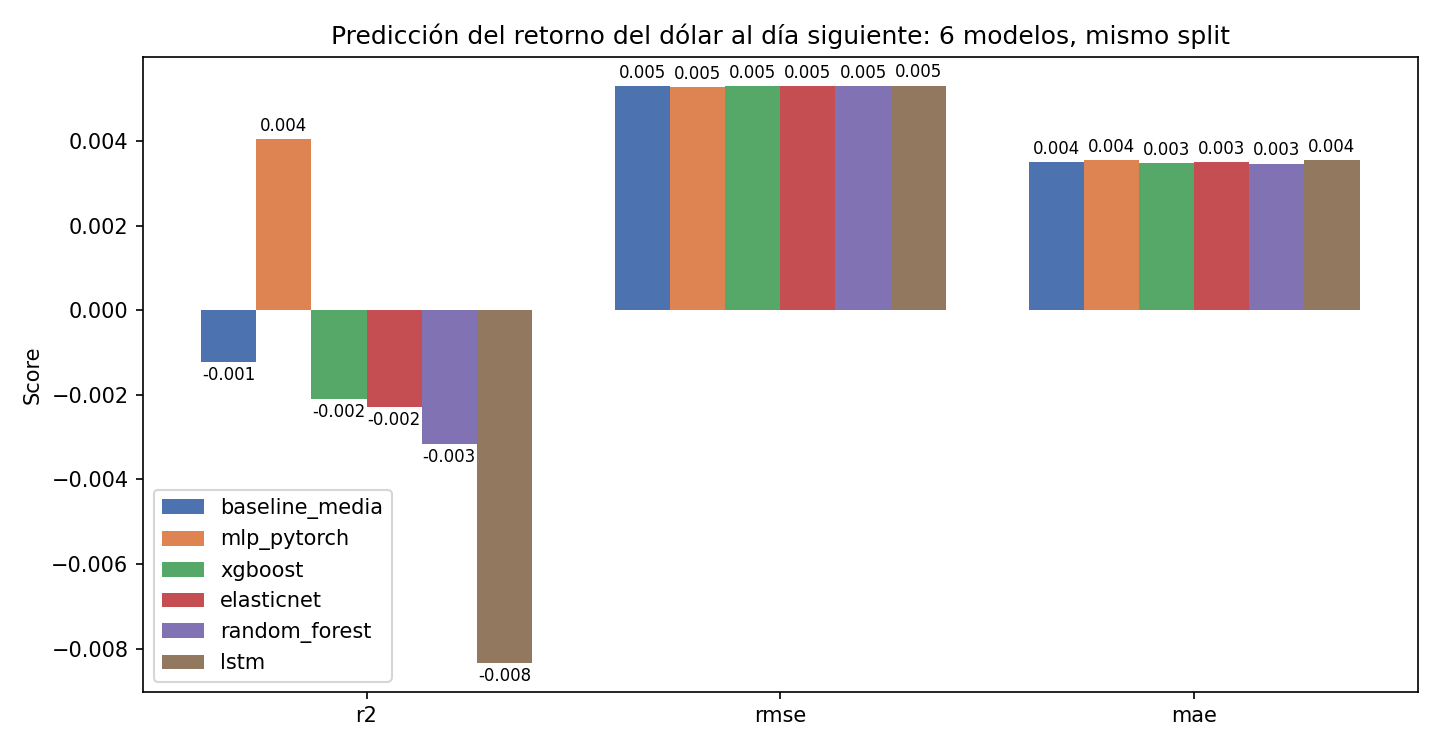

In [10]:
from IPython.display import Image, display
display(Image(filename="../outputs/financial/figures/model_comparison.png"))


## Conclusiones

- El panel financiero real tiene desalineación de frecuencias (diario vs.
  mensual) como su desafío de limpieza central, no valores corruptos -- salvo
  un error real encontrado y corregido en la fuente (UF, dic-2014).
- Ningún modelo bate de forma significativa a un baseline trivial en el
  retorno diario del dólar -- un resultado honesto y esperado, no una falla
  del pipeline.
